# 02 · Feature engineering

The raw data is already PCA-transformed, so we can't read the original columns. Instead we build features *on top* of what we have — the kind a real fraud team engineers:

1. **Synthetic cardholders** — recover pseudo-users by clustering, so we can ask *"is this spend normal for this person?"*
2. **Velocity** — how many transactions happened in a short window before this one (card-testing attacks burst).
3. **Personal deviation** — z-score of the amount against the cardholder's own history.
4. **Cyclic time** — sine/cosine of time-of-day so the model sees that 23:59 and 00:01 are adjacent.
5. **Amount transforms** — log amount and coarse buckets.

> The cardholders are an **approximation** (the dataset has no user id). We cluster on PCA features and treat each cluster as one person. Never claim these are real users — but they're enough to demonstrate the feature.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fraud_utils as fu

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")
ART = fu.ARTIFACTS_DIR
RNG = np.random.default_rng(42)

In [2]:
df = pd.read_parquet(os.path.join(ART, '01_data.parquet'))
print(df.shape)
df.head(3)

(60200, 33)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,month,is_drift
0,0.6208,1.3320,-0.0748,-0.0147,-0.6127,0.9654,-0.9830,-1.5980,-0.2184,-1.7556,...,-0.7487,0.8489,-0.4405,1.7441,0.1864,0.0759,23.5367,0,1,False
1,0.7188,1.2145,-1.5864,-2.4253,-0.8336,-0.1448,-0.4913,-0.4932,-1.8426,0.2492,...,-0.0906,-1.3517,1.2006,-1.4504,-0.1539,1.0962,82.2253,0,1,False
2,1.4291,0.8590,-0.9320,0.9804,0.1563,0.0140,-0.8075,0.2232,0.8028,-0.7308,...,1.0361,0.8719,-0.7069,-0.4461,-0.3542,-0.2008,236.5002,0,1,False


## 1 · Synthetic cardholders
K-Means over the PCA features. Each cluster becomes a `card_id`.

In [3]:
df = fu.assign_synthetic_cardholders(df, n_cards=300)
print('pseudo-cardholders:', df['card_id'].nunique())
df['card_id'].value_counts().head()

pseudo-cardholders: 300


card_id
161    286
211    266
180    262
31     260
296    256
Name: count, dtype: int64

## 2 · Transaction velocity

For each transaction, count how many transactions occurred in the preceding `window` seconds. We sort by `Time` and use `searchsorted`, which is O(n log n) instead of a slow loop.

In [4]:
def velocity(times, window=3600):
    t = np.sort(times.values)
    order = np.argsort(times.values)
    # for each t_i, index of first txn within [t_i - window, t_i]
    left = np.searchsorted(t, t - window, side='left')
    counts_sorted = np.arange(len(t)) - left
    counts = np.empty(len(t), dtype=int)
    counts[order] = counts_sorted
    return counts

df['velocity_1h'] = velocity(df['Time'], window=3600)
df['velocity_10m'] = velocity(df['Time'], window=600)
df[['Time', 'velocity_10m', 'velocity_1h']].describe()

,Time,velocity_10m,velocity_1h
count,"60,200.0000","60,200.0000","60,200.0000"
mean,"86,377.9372",208.6175,"1,240.6375"
std,"49,867.0283",15.8471,109.4526
min,0.6208,0.0000,0.0000
25%,"43,104.0940",200.0000,"1,229.0000"
50%,"86,289.1082",209.0000,"1,253.0000"
75%,"129,867.4275",219.0000,"1,277.0000"
max,"172,791.4144",257.0000,"1,349.0000"


## 3 · Deviation from the cardholder's normal spend

z-score of `Amount` within each pseudo-cardholder. A transaction far above someone's usual amount is suspicious in a way the raw amount can't capture.

In [5]:
grp = df.groupby('card_id')['Amount']
card_mean = grp.transform('mean')
card_std = grp.transform('std').replace(0, np.nan)
df['amount_z'] = ((df['Amount'] - card_mean) / card_std).fillna(0.0)
df[['Amount', 'amount_z']].describe()

,Amount,amount_z
count,"60,200.0000","60,200.0000"
mean,99.9652,-0.0000
std,70.8002,0.9975
min,0.2426,-1.6207
25%,47.9951,-0.7362
50%,84.0750,-0.2228
75%,134.7967,0.4930
max,777.5156,7.8540


## 4 · Cyclic time-of-day

`Time` is seconds since the first transaction. Take it modulo a day, then encode as sine and cosine so the model treats midnight as continuous.

In [6]:
seconds_in_day = df['Time'] % 86400
angle = 2 * np.pi * seconds_in_day / 86400
df['tod_sin'] = np.sin(angle)
df['tod_cos'] = np.cos(angle)
df[['Time', 'tod_sin', 'tod_cos']].head()

,Time,tod_sin,tod_cos
0,0.6208,0.0000,1.0000
1,0.7188,0.0001,1.0000
2,1.4291,0.0001,1.0000
3,5.3931,0.0004,1.0000
4,7.3443,0.0005,1.0000


## 5 · Amount transforms

In [7]:
df['amount_log'] = np.log1p(df['Amount'])
df['amount_bucket'] = pd.qcut(df['Amount'].rank(method='first'),
                              q=5, labels=False)
df[['Amount', 'amount_log', 'amount_bucket']].head()

,Amount,amount_log,amount_bucket
0,23.5367,3.2002,0
1,82.2253,4.4216,2
2,236.5002,5.4702,4
3,308.4785,5.7349,4
4,209.1286,5.3477,4


## Which engineered features actually carry signal?

Correlation of each new feature with `Class`. Small absolute values are normal for individual features — the models combine them.

amount_log      -0.0345
amount_bucket   -0.0265
velocity_10m     0.0114
tod_sin         -0.0078
velocity_1h      0.0042
amount_z        -0.0042
tod_cos          0.0002
Name: Class, dtype: float64


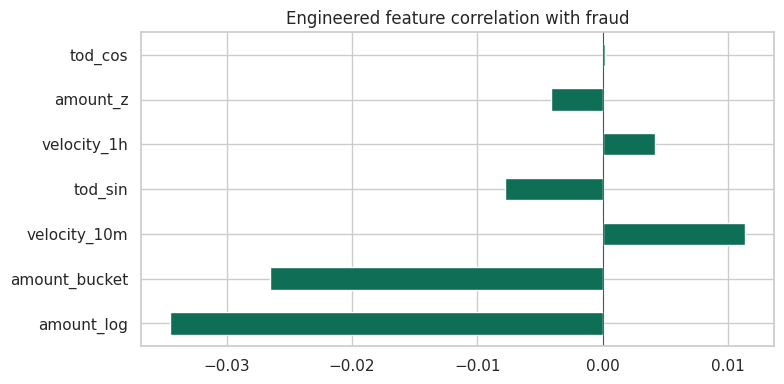

In [8]:
eng = ['velocity_10m', 'velocity_1h', 'amount_z',
       'tod_sin', 'tod_cos', 'amount_log', 'amount_bucket']
corr_class = (df[eng + ['Class']].corr()['Class']
              .drop('Class').sort_values(key=abs, ascending=False))
print(corr_class)

fig, ax = plt.subplots(figsize=(8, 4))
corr_class.plot(kind='barh', ax=ax, color='#0F6E56')
ax.set_title('Engineered feature correlation with fraud')
ax.axvline(0, color='k', lw=.5)
plt.tight_layout(); plt.show()

In [9]:
out = os.path.join(ART, '02_features.parquet')
df.to_parquet(out, index=False)
print('saved', out, df.shape)
print('columns:', list(df.columns))

saved /home/claude/fraud-detection-research/artifacts/02_features.parquet (60200, 41)
columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'month', 'is_drift', 'card_id', 'velocity_1h', 'velocity_10m', 'amount_z', 'tod_sin', 'tod_cos', 'amount_log', 'amount_bucket']


### Takeaways
- We added behavioural features (velocity, personal deviation) that the raw PCA columns can't express.
- Cyclic encoding lets the model use time-of-day correctly.
- These features will matter most for the tree models, which can carve sharp rules on `velocity` and `amount_z`.

Next: the model arena — five models, one split, one preprocessing pipeline.